# Assignment 15 — Model Compression
### CNN Classification, Knowledge Distillation, Pruning & Quantization
**Dataset:** CIFAR-10 (10 classes, 32×32 RGB images)

In [1]:
!pip install -q tensorflow tensorflow-model-optimization scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 7.2 MB/s eta 0:00:00


## Step 1 — Imports & Dataset (CIFAR-10)

TensorFlow version: 2.20.0
170498071/170498071 [==============================] - 5s 0us/step
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


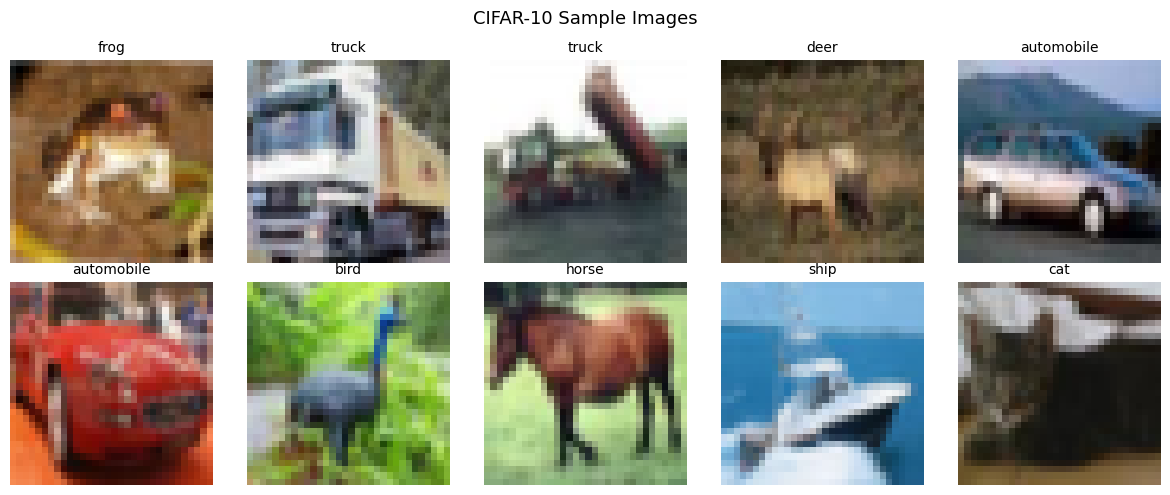

In [2]:
import tensorflow as tf
import numpy as np
import time
import os
import tensorflow_model_optimization as tfmot
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

# Load CIFAR-10 (10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

y_train = y_train.flatten()
y_test  = y_test.flatten()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f'Train: {x_train.shape}, Test: {x_test.shape}')

# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=13)
plt.tight_layout()
plt.show()

## Step 2 — Lightweight CNN (Student Model) — Built from Scratch

In [3]:
def build_student_cnn():
    """Lightweight CNN for CIFAR-10 (32x32x3 input)."""
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32, 32, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation='softmax')
    ], name='student_cnn')
    return model

student_model = build_student_cnn()
student_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
student_model.summary()

Model: "student_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 16, 16, 64)        256       
 chNormalization)                                                
                                                       

## Step 3 — Train Student CNN

Epoch 1/30
704/704 [==============================] - 11s 7ms/step - loss: 1.3761 - accuracy: 0.5017 - val_loss: 1.2738 - val_accuracy: 0.5574 - lr: 0.0010
Epoch 2/30
704/704 [==============================] - 4s 6ms/step - loss: 1.0120 - accuracy: 0.6410 - val_loss: 1.1041 - val_accuracy: 0.6068 - lr: 0.0010
Epoch 3/30
704/704 [==============================] - 5s 7ms/step - loss: 0.8610 - accuracy: 0.6979 - val_loss: 0.9155 - val_accuracy: 0.6730 - lr: 0.0010
Epoch 4/30
704/704 [==============================] - 4s 6ms/step - loss: 0.7550 - accuracy: 0.7358 - val_loss: 0.9448 - val_accuracy: 0.6708 - lr: 0.0010
Epoch 5/30
704/704 [==============================] - 4s 6ms/step - loss: 0.6874 - accuracy: 0.7622 - val_loss: 1.0426 - val_accuracy: 0.6632 - lr: 0.0010
Epoch 6/30
704/704 [==============================] - 5s 7ms/step - loss: 0.6191 - accuracy: 0.7855 - val_loss: 0.9006 - val_accuracy: 0.6990 - lr: 0.0010
Epoch 7/30
704/704 [==============================] - 4s 6ms/step - l

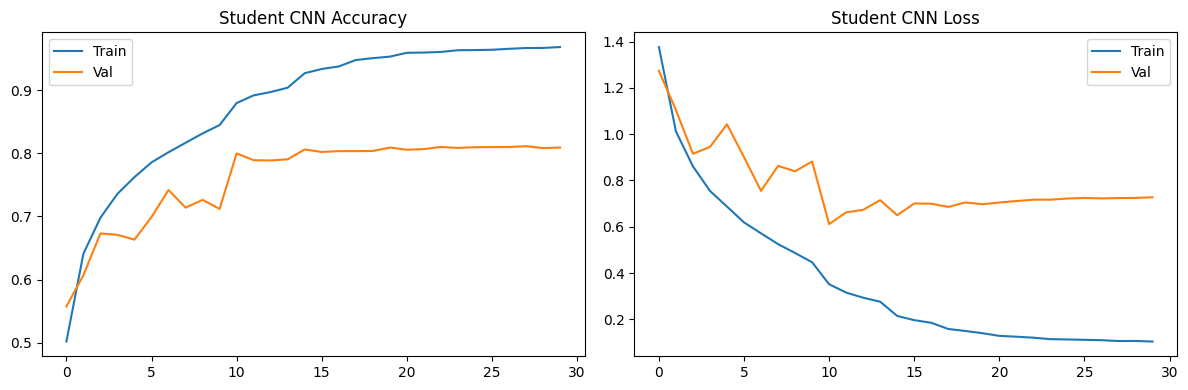

In [4]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

history_student = student_model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_student.history['accuracy'], label='Train')
axes[0].plot(history_student.history['val_accuracy'], label='Val')
axes[0].set_title('Student CNN Accuracy')
axes[0].legend()
axes[1].plot(history_student.history['loss'], label='Train')
axes[1].plot(history_student.history['val_loss'], label='Val')
axes[1].set_title('Student CNN Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 4 — Teacher 1: ResNet50 (Fine-Tuned on CIFAR-10)

In [5]:
BATCH_SIZE = 32

def make_resnet_dataset(x, y, shuffle=False):
    """Create tf.data pipeline with ResNet50 preprocessing."""
    def preprocess(image, label):
        image = tf.image.resize(image, (224, 224))
        image = tf.keras.applications.resnet50.preprocess_input(image * 255.0)
        return image, label
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(10000)
    return ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds_resnet = make_resnet_dataset(x_train, y_train, shuffle=True)
test_ds_resnet  = make_resnet_dataset(x_test,  y_test)

# Load ResNet50 without top, imagenet weights
base1 = tf.keras.applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
# Freeze all except last 30 layers
base1.trainable = True
for layer in base1.layers[:-30]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base1(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

teacher1 = tf.keras.Model(inputs, outputs, name='teacher_resnet50')
teacher1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
teacher1.summary()

94765736/94765736 [==============================] - 1s 0us/step
Model: "teacher_resnet50"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_2 (Dense)             (None, 256)               524544    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 128)           

Epoch 1/10
1563/1563 [==============================] - 243s 149ms/step - loss: 0.4965 - accuracy: 0.8489 - val_loss: 0.3622 - val_accuracy: 0.8951
Epoch 2/10
1563/1563 [==============================] - 242s 155ms/step - loss: 0.2368 - accuracy: 0.9289 - val_loss: 0.2427 - val_accuracy: 0.9273
Epoch 3/10
1563/1563 [==============================] - 244s 156ms/step - loss: 0.1577 - accuracy: 0.9523 - val_loss: 0.2321 - val_accuracy: 0.9309
Epoch 4/10
1563/1563 [==============================] - 241s 154ms/step - loss: 0.1169 - accuracy: 0.9653 - val_loss: 0.2871 - val_accuracy: 0.9263
Epoch 5/10
1563/1563 [==============================] - 240s 153ms/step - loss: 0.0845 - accuracy: 0.9748 - val_loss: 0.2758 - val_accuracy: 0.9359
Epoch 6/10
1563/1563 [==============================] - 244s 156ms/step - loss: 0.0659 - accuracy: 0.9810 - val_loss: 0.3567 - val_accuracy: 0.9154
Epoch 7/10
1563/1563 [==============================] - 253s 162ms/step - loss: 0.0583 - accuracy: 0.9828 - val_

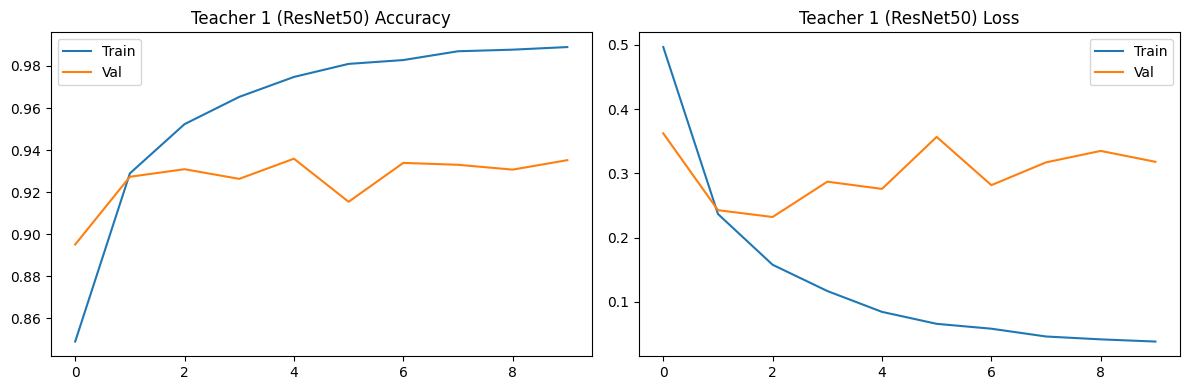

In [6]:
history_teacher1 = teacher1.fit(
    train_ds_resnet,
    epochs=10,
    validation_data=test_ds_resnet,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_teacher1.history['accuracy'], label='Train')
axes[0].plot(history_teacher1.history['val_accuracy'], label='Val')
axes[0].set_title('Teacher 1 (ResNet50) Accuracy')
axes[0].legend()
axes[1].plot(history_teacher1.history['loss'], label='Train')
axes[1].plot(history_teacher1.history['val_loss'], label='Val')
axes[1].set_title('Teacher 1 (ResNet50) Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 5 — Teacher 2: MobileNetV2 (Fine-Tuned on CIFAR-10)

In [7]:
def make_mobilenet_dataset(x, y, shuffle=False):
    """Create tf.data pipeline with MobileNetV2 preprocessing."""
    def preprocess(image, label):
        image = tf.image.resize(image, (224, 224))
        image = tf.keras.applications.mobilenet_v2.preprocess_input(image * 255.0)
        return image, label
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(10000)
    return ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds_mobilenet = make_mobilenet_dataset(x_train, y_train, shuffle=True)
test_ds_mobilenet  = make_mobilenet_dataset(x_test,  y_test)

# Load MobileNetV2 without top
base2 = tf.keras.applications.MobileNetV2(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base2.trainable = True
for layer in base2.layers[:-30]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base2(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

teacher2 = tf.keras.Model(inputs, outputs, name='teacher_mobilenetv2')
teacher2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
teacher2.summary()

9406464/9406464 [==============================] - 0s 0us/step
Model: "teacher_mobilenetv2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_5 (Dense)             (None, 256)               327936    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                  

Epoch 1/10
1563/1563 [==============================] - 100s 58ms/step - loss: 0.6306 - accuracy: 0.7999 - val_loss: 0.4017 - val_accuracy: 0.8713
Epoch 2/10
1563/1563 [==============================] - 88s 56ms/step - loss: 0.3375 - accuracy: 0.8967 - val_loss: 0.3444 - val_accuracy: 0.8941
Epoch 3/10
1563/1563 [==============================] - 89s 57ms/step - loss: 0.2507 - accuracy: 0.9228 - val_loss: 0.3136 - val_accuracy: 0.9010
Epoch 4/10
1563/1563 [==============================] - 99s 63ms/step - loss: 0.1878 - accuracy: 0.9409 - val_loss: 0.3001 - val_accuracy: 0.9076
Epoch 5/10
1563/1563 [==============================] - 91s 58ms/step - loss: 0.1468 - accuracy: 0.9533 - val_loss: 0.3317 - val_accuracy: 0.9095
Epoch 6/10
1563/1563 [==============================] - 89s 57ms/step - loss: 0.1164 - accuracy: 0.9635 - val_loss: 0.3056 - val_accuracy: 0.9178
Epoch 7/10
1563/1563 [==============================] - 89s 57ms/step - loss: 0.0910 - accuracy: 0.9712 - val_loss: 0.3294 

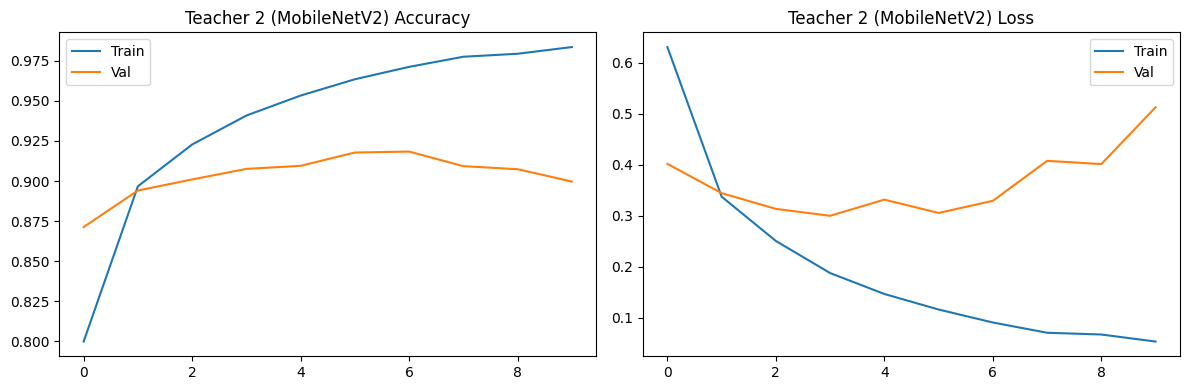

In [8]:
history_teacher2 = teacher2.fit(
    train_ds_mobilenet,
    epochs=10,
    validation_data=test_ds_mobilenet,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_teacher2.history['accuracy'], label='Train')
axes[0].plot(history_teacher2.history['val_accuracy'], label='Val')
axes[0].set_title('Teacher 2 (MobileNetV2) Accuracy')
axes[0].legend()
axes[1].plot(history_teacher2.history['loss'], label='Train')
axes[1].plot(history_teacher2.history['val_loss'], label='Val')
axes[1].set_title('Teacher 2 (MobileNetV2) Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 6 — Knowledge Distillation: Teacher 1 (ResNet50) → Student

The distillation loss combines:
- **Hard loss**: Cross-entropy between student predictions and true labels
- **Soft loss**: KL-divergence between softened teacher and student logits (controlled by temperature T)
- **alpha**: blending weight between hard and soft loss

In [9]:
def distillation_loss(y_true, y_pred_logits, teacher_probs, temperature=5.0, alpha=0.5):
    """
    Knowledge Distillation loss.
    y_true         : integer class labels
    y_pred_logits  : student output (softmax probabilities)
    teacher_probs  : teacher output (softmax probabilities)
    temperature    : softening factor T
    alpha          : weight for hard loss
    """
    # Hard loss (student vs ground truth)
    hard_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred_logits)

    # Soft labels — apply temperature to student logits and teacher probs
    # Convert student softmax output back to logits via log for temperature scaling
    student_soft = tf.nn.softmax(tf.math.log(y_pred_logits + 1e-8) / temperature)
    teacher_soft = tf.nn.softmax(tf.math.log(teacher_probs + 1e-8) / temperature)

    # KL Divergence: sum(teacher_soft * log(teacher_soft / student_soft))
    soft_loss = tf.keras.losses.KLDivergence()(teacher_soft, student_soft)

    return alpha * hard_loss + (1 - alpha) * (temperature ** 2) * soft_loss

Generating Teacher 1 soft labels...
1563/1563 [==============================] - 165s 104ms/step
Epoch 1/10  distillation loss: 9.3335
Epoch 2/10  distillation loss: 6.5402
Epoch 3/10  distillation loss: 5.3623
Epoch 4/10  distillation loss: 4.6236
Epoch 5/10  distillation loss: 4.1014
Epoch 6/10  distillation loss: 3.6927
Epoch 7/10  distillation loss: 3.3564
Epoch 8/10  distillation loss: 3.0625
Epoch 9/10  distillation loss: 2.8195
Epoch 10/10  distillation loss: 2.6117


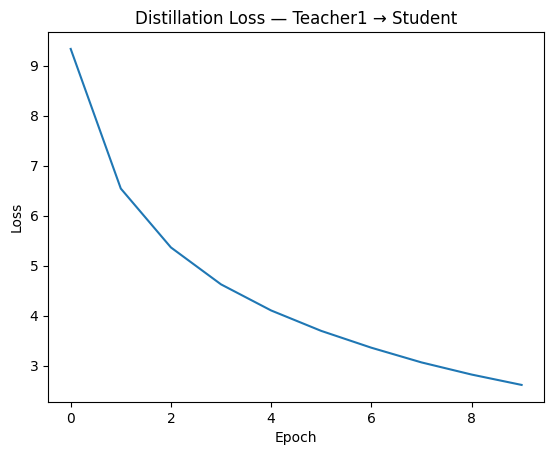

In [10]:
import tensorflow as tf

# ---- Distillation: Teacher 1 (ResNet50) → Student ----

DISTILL_BATCH = 64
DISTILL_EPOCHS = 10

# 1. Get teacher1 predictions on CIFAR-10 training images (resized to 224x224)
print("Generating Teacher 1 soft labels...")
train_ds_kd1 = make_resnet_dataset(x_train, y_train, shuffle=False)
teacher_preds1 = teacher1.predict(train_ds_kd1, verbose=1)   # shape: (50000, 10)

# 2. Build a fresh student model
student_distilled_1 = build_student_cnn()
optimizer_kd1 = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Define the training step as a tf.function to prevent retracing warnings
@tf.function
def train_step(x_batch, y_batch, t_batch):
    with tf.GradientTape() as tape:
        preds = student_distilled_1(x_batch, training=True)
        loss  = distillation_loss(y_batch, preds, t_batch)
        loss  = tf.reduce_mean(loss)

    grads = tape.gradient(loss, student_distilled_1.trainable_variables)
    optimizer_kd1.apply_gradients(zip(grads, student_distilled_1.trainable_variables))
    return loss

# 3. Distillation training loop
distill1_losses = []
N = len(x_train)

for epoch in range(DISTILL_EPOCHS):
    epoch_loss = 0.0
    steps = 0
    for i in range(0, N, DISTILL_BATCH):
        x_batch = x_train[i:i + DISTILL_BATCH]
        y_batch = y_train[i:i + DISTILL_BATCH]
        t_batch = teacher_preds1[i:i + DISTILL_BATCH]

        # Execute the tf.function wrapped train step
        loss = train_step(tf.constant(x_batch), tf.constant(y_batch), tf.constant(t_batch))
        epoch_loss += loss.numpy()
        steps += 1

    avg_loss = epoch_loss / steps
    distill1_losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{DISTILL_EPOCHS}  distillation loss: {avg_loss:.4f}')

plt.plot(distill1_losses)
plt.title('Distillation Loss — Teacher1 → Student')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Step 7 — Knowledge Distillation: Teacher 2 (MobileNetV2) → Student

Generating Teacher 2 soft labels...
1563/1563 [==============================] - 59s 37ms/step


Epoch 1/10  distillation loss: 8.1881
Epoch 2/10  distillation loss: 5.6800
Epoch 3/10  distillation loss: 4.6172
Epoch 4/10  distillation loss: 3.9875
Epoch 5/10  distillation loss: 3.5099
Epoch 6/10  distillation loss: 3.1854
Epoch 7/10  distillation loss: 2.8980
Epoch 8/10  distillation loss: 2.6575
Epoch 9/10  distillation loss: 2.4534
Epoch 10/10  distillation loss: 2.2977


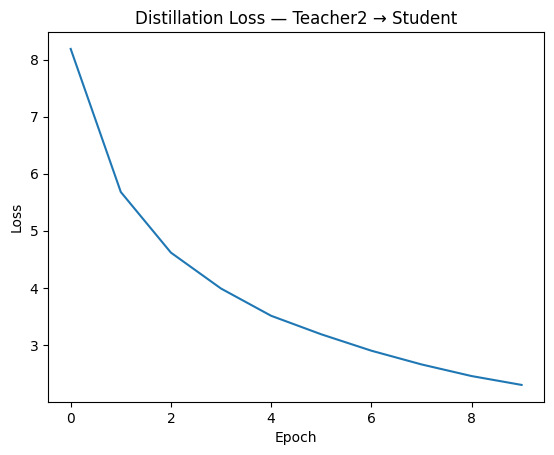

In [11]:
# ---- Distillation: Teacher 2 (MobileNetV2) → Student ----

# 1. Get teacher2 predictions
print("Generating Teacher 2 soft labels...")
train_ds_kd2 = make_mobilenet_dataset(x_train, y_train, shuffle=False)
teacher_preds2 = teacher2.predict(train_ds_kd2, verbose=1)   # shape: (50000, 10)

# 2. Fresh student model
student_distilled_2 = build_student_cnn()
optimizer_kd2 = tf.keras.optimizers.Adam(learning_rate=1e-3)

# 3. Distillation training loop
distill2_losses = []

for epoch in range(DISTILL_EPOCHS):
    epoch_loss = 0.0
    steps = 0
    for i in range(0, N, DISTILL_BATCH):
        x_batch = x_train[i:i + DISTILL_BATCH]
        y_batch = y_train[i:i + DISTILL_BATCH]
        t_batch = teacher_preds2[i:i + DISTILL_BATCH]  # BUG FIX: was i//DISTILL_BATCH

        with tf.GradientTape() as tape:
            preds = student_distilled_2(x_batch, training=True)
            loss  = distillation_loss(y_batch, preds, t_batch)
            loss  = tf.reduce_mean(loss)

        grads = tape.gradient(loss, student_distilled_2.trainable_variables)
        optimizer_kd2.apply_gradients(zip(grads, student_distilled_2.trainable_variables))
        epoch_loss += loss.numpy()
        steps += 1

    avg_loss = epoch_loss / steps
    distill2_losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{DISTILL_EPOCHS}  distillation loss: {avg_loss:.4f}')

plt.plot(distill2_losses)
plt.title('Distillation Loss — Teacher2 → Student')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Step 8 — Baseline Evaluation of All 5 Original Models

In [12]:
def get_model_size_mb(model, path='temp_eval_model.h5'):
    """Save model and return size in MB."""
    model.save(path)
    size = os.path.getsize(path) / (1024 * 1024)
    os.remove(path)
    return round(size, 3)

def get_param_count(model):
    return model.count_params()

def evaluate_keras_model(model, name, x, y, ds=None):
    """
    Evaluate a Keras model.
    If ds is provided, use it for inference (teacher models with large input).
    Otherwise use x directly (student models).
    """
    start = time.time()
    if ds is not None:
        preds = model.predict(ds, verbose=0)
    else:
        preds = model.predict(x, batch_size=64, verbose=0)
    elapsed = time.time() - start

    y_pred = np.argmax(preds, axis=1)
    acc    = accuracy_score(y, y_pred)
    prec   = precision_score(y, y_pred, average='macro', zero_division=0)
    rec    = recall_score(y, y_pred, average='macro', zero_division=0)
    f1     = f1_score(y, y_pred, average='macro', zero_division=0)
    size   = get_model_size_mb(model)
    params = get_param_count(model)

    result = {
        'name':       name,
        'accuracy':   round(acc, 4),
        'precision':  round(prec, 4),
        'recall':     round(rec, 4),
        'f1':         round(f1, 4),
        'size_mb':    size,
        'params':     params,
        'infer_sec':  round(elapsed, 3),
    }
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Model size: {size} MB")
    print(f"  Parameters: {params:,}")
    print(f"  Infer time: {elapsed:.3f} s")
    print(classification_report(y, y_pred, target_names=class_names))
    return result

results = {}

# Evaluate all 5 original (uncompressed) models
results['student_base']   = evaluate_keras_model(student_model,       'Student CNN (Baseline)',       x_test, y_test)
results['teacher1']       = evaluate_keras_model(teacher1,            'Teacher 1 — ResNet50',        x_test, y_test, ds=make_resnet_dataset(x_test, y_test))
results['teacher2']       = evaluate_keras_model(teacher2,            'Teacher 2 — MobileNetV2',     x_test, y_test, ds=make_mobilenet_dataset(x_test, y_test))
results['student_dist1']  = evaluate_keras_model(student_distilled_1, 'Student Distilled (T1-ResNet)',x_test, y_test)
results['student_dist2']  = evaluate_keras_model(student_distilled_2, 'Student Distilled (T2-Mobile)',x_test, y_test)

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Student CNN (Baseline)
  Accuracy  : 0.7977
  Precision : 0.7971
  Recall    : 0.7977
  F1-Score  : 0.7973
  Model size: 1.35 MB
  Parameters: 111,946
  Infer time: 1.128 s
              precision    recall  f1-score   support

    airplane       0.80      0.83      0.82      1000
  automobile       0.88      0.88      0.88      1000
        bird       0.71      0.70      0.71      1000
         cat       0.67      0.64      0.65      1000
        deer       0.75      0.78      0.77      1000
         dog       0.73      0.72      0.73      1000
        frog       0.82      0.84      0.83      1000
       horse       0.84      0.84      0.84      1000
        ship       0.89      0.89      0.89      1000
       truck       0.87      0.86      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Teacher 1 — ResNet50
  Accuracy  : 0.9352
  Precision : 0.9364
  Recall    : 0.9352
  F1-Score  : 0.9353
  Model size: 207.036 MB
  Parameters: 24,146,442
  Infer time: 33.247 s
              precision    recall  f1-score   support

    airplane       0.95      0.96      0.95      1000
  automobile       0.95      0.97      0.96      1000
        bird       0.92      0.93      0.92      1000
         cat       0.89      0.83      0.86      1000
        deer       0.95      0.92      0.93      1000
         dog       0.83      0.94      0.88      1000
        frog       0.98      0.95      0.96      1000
       horse       0.96      0.95      0.96      1000
        ship       0.96      0.97      0.97      1000
       truck       0.97      0.94      0.95      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Teacher 2 — MobileNetV2
  Accuracy  : 0.8997
  Precision : 0.9052
  Recall    : 0.8997
  F1-Score  : 0.9000
  Model size: 24.798 MB
  Parameters: 2,620,106
  Infer time: 11.703 s
              precision    recall  f1-score   support

    airplane       0.95      0.90      0.93      1000
  automobile       0.96      0.96      0.96      1000
        bird       0.83      0.94      0.88      1000
         cat       0.84      0.76      0.80      1000
        deer       0.84      0.93      0.88      1000
         dog       0.78      0.90      0.83      1000
        frog       0.99      0.80      0.89      1000
       horse       0.97      0.90      0.93      1000
        ship       0.96      0.94      0.95      1000
       truck       0.94      0.96      0.95      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Student Distilled (T1-ResNet)
  Accuracy  : 0.7381
  Precision : 0.7582
  Recall    : 0.7381
  F1-Score  : 0.7366
  Model size: 0.466 MB
  Parameters: 111,946
  Infer time: 0.772 s
              precision    recall  f1-score   support

    airplane       0.86      0.68      0.76      1000
  automobile       0.95      0.73      0.83      1000
        bird       0.81      0.56      0.66      1000
         cat       0.63      0.55      0.58      1000
        deer       0.77      0.62      0.69      1000
         dog       0.58      0.79      0.67      1000
        frog       0.71      0.88      0.79      1000
       horse       0.82      0.75      0.78      1000
        ship       0.82      0.87      0.84      1000
       truck       0.64      0.95      0.76      1000

    accuracy                           0.74     10000
   macro avg       0.76      0.74      0.74     10000
weighted avg       0.76      0.74      0.74     10000



/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Student Distilled (T2-Mobile)
  Accuracy  : 0.7458
  Precision : 0.7646
  Recall    : 0.7458
  F1-Score  : 0.7473
  Model size: 0.466 MB
  Parameters: 111,946
  Infer time: 0.744 s
              precision    recall  f1-score   support

    airplane       0.89      0.67      0.77      1000
  automobile       0.92      0.81      0.87      1000
        bird       0.77      0.57      0.65      1000
         cat       0.53      0.67      0.59      1000
        deer       0.68      0.74      0.71      1000
         dog       0.64      0.72      0.68      1000
        frog       0.86      0.67      0.75      1000
       horse       0.82      0.79      0.80      1000
        ship       0.84      0.86      0.85      1000
       truck       0.69      0.95      0.80      1000

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000



## Step 9 — Pruning All Models

We apply **magnitude-based unstructured pruning** (80% sparsity) to all 5 models.
For functional (teacher) models, we re-fine-tune after stripping pruning wrappers.

In [13]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

def get_pruning_params(end_step):
    return {
        'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.30,
            final_sparsity=0.80,
            begin_step=0,
            end_step=end_step
        )
    }

def prune_and_finetune_student(model, x_tr, y_tr, epochs=5, batch_size=64):
    """Prune a Sequential/student model and fine-tune."""
    end_step = np.ceil(len(x_tr) / batch_size).astype(int) * epochs
    pruned = prune_low_magnitude(model, **get_pruning_params(end_step))
    pruned.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    pruned.fit(
        x_tr, y_tr,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
        verbose=1
    )
    stripped = tfmot.sparsity.keras.strip_pruning(pruned)
    return stripped

def prune_and_finetune_teacher(model, train_ds, val_ds, epochs=3):
    """Prune a functional/teacher model (ResNet / MobileNet) and fine-tune."""
    end_step = np.ceil(len(x_train) / BATCH_SIZE).astype(int) * epochs
    pruned = prune_low_magnitude(model, **get_pruning_params(end_step))
    pruned.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    pruned.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
        verbose=1
    )
    stripped = tfmot.sparsity.keras.strip_pruning(pruned)
    return stripped

print("=== Pruning Student Baseline ===")
student_pruned = prune_and_finetune_student(student_model, x_train, y_train)

print("\n=== Pruning Teacher 1 (ResNet50) ===")
teacher1_pruned = prune_and_finetune_teacher(teacher1, train_ds_resnet, test_ds_resnet)

print("\n=== Pruning Teacher 2 (MobileNetV2) ===")
teacher2_pruned = prune_and_finetune_teacher(teacher2, train_ds_mobilenet, test_ds_mobilenet)

print("\n=== Pruning Distilled Student 1 ===")
student_dist1_pruned = prune_and_finetune_student(student_distilled_1, x_train, y_train)

print("\n=== Pruning Distilled Student 2 ===")
student_dist2_pruned = prune_and_finetune_student(student_distilled_2, x_train, y_train)

=== Pruning Student Baseline ===
Epoch 1/5
704/704 [==============================] - 17s 14ms/step - loss: 0.3449 - accuracy: 0.8778 - val_loss: 1.5903 - val_accuracy: 0.5372
Epoch 2/5
704/704 [==============================] - 8s 12ms/step - loss: 0.4563 - accuracy: 0.8412 - val_loss: 1.2442 - val_accuracy: 0.6142
Epoch 3/5
704/704 [==============================] - 7s 10ms/step - loss: 0.5490 - accuracy: 0.8084 - val_loss: 1.7238 - val_accuracy: 0.4842
Epoch 4/5
704/704 [==============================] - 8s 12ms/step - loss: 0.5869 - accuracy: 0.7968 - val_loss: 0.8249 - val_accuracy: 0.7208
Epoch 5/5
704/704 [==============================] - 8s 12ms/step - loss: 0.5487 - accuracy: 0.8098 - val_loss: 0.7426 - val_accuracy: 0.7554

=== Pruning Teacher 1 (ResNet50) ===
Epoch 1/3
1563/1563 [==============================] - 273s 167ms/step - loss: 0.0080 - accuracy: 0.9980 - val_loss: 0.3024 - val_accuracy: 0.9468
Epoch 2/3
1563/1563 [==============================] - 251s 161ms/step 

In [14]:
# Evaluate all pruned models
results['student_base_pruned']  = evaluate_keras_model(student_pruned,       'Student CNN — Pruned',         x_test, y_test)
results['teacher1_pruned']      = evaluate_keras_model(teacher1_pruned,      'Teacher1 ResNet50 — Pruned',   x_test, y_test, ds=make_resnet_dataset(x_test, y_test))
results['teacher2_pruned']      = evaluate_keras_model(teacher2_pruned,      'Teacher2 MobileNetV2 — Pruned',x_test, y_test, ds=make_mobilenet_dataset(x_test, y_test))
results['student_dist1_pruned'] = evaluate_keras_model(student_dist1_pruned, 'Distilled T1 — Pruned',        x_test, y_test)
results['student_dist2_pruned'] = evaluate_keras_model(student_dist2_pruned, 'Distilled T2 — Pruned',        x_test, y_test)

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Student CNN — Pruned
  Accuracy  : 0.7450
  Precision : 0.7594
  Recall    : 0.7450
  F1-Score  : 0.7460
  Model size: 0.466 MB
  Parameters: 111,946
  Infer time: 1.456 s
              precision    recall  f1-score   support

    airplane       0.63      0.87      0.73      1000
  automobile       0.80      0.92      0.85      1000
        bird       0.74      0.59      0.66      1000
         cat       0.55      0.66      0.60      1000
        deer       0.72      0.69      0.71      1000
         dog       0.69      0.67      0.68      1000
        frog       0.89      0.68      0.77      1000
       horse       0.82      0.78      0.80      1000
        ship       0.84      0.85      0.85      1000
       truck       0.92      0.74      0.82      1000

    accuracy                           0.74     10000
   macro avg       0.76      0.74      0.75     10000
weighted avg       0.76      0.74      0.75     10000



/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Teacher1 ResNet50 — Pruned
  Accuracy  : 0.9468
  Precision : 0.9470
  Recall    : 0.9468
  F1-Score  : 0.9467
  Model size: 92.45 MB
  Parameters: 24,146,442
  Infer time: 43.231 s
              precision    recall  f1-score   support

    airplane       0.96      0.96      0.96      1000
  automobile       0.95      0.98      0.97      1000
        bird       0.97      0.92      0.94      1000
         cat       0.90      0.88      0.89      1000
        deer       0.94      0.96      0.95      1000
         dog       0.89      0.92      0.91      1000
        frog       0.95      0.97      0.96      1000
       horse       0.97      0.95      0.96      1000
        ship       0.97      0.98      0.97      1000
       truck       0.97      0.95      0.96      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Teacher2 MobileNetV2 — Pruned
  Accuracy  : 0.9237
  Precision : 0.9240
  Recall    : 0.9237
  F1-Score  : 0.9236
  Model size: 10.312 MB
  Parameters: 2,620,106
  Infer time: 21.318 s
              precision    recall  f1-score   support

    airplane       0.92      0.95      0.93      1000
  automobile       0.96      0.97      0.97      1000
        bird       0.93      0.90      0.91      1000
         cat       0.86      0.81      0.84      1000
        deer       0.90      0.92      0.91      1000
         dog       0.84      0.89      0.87      1000
        frog       0.94      0.94      0.94      1000
       horse       0.95      0.94      0.95      1000
        ship       0.96      0.96      0.96      1000
       truck       0.97      0.95      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Distilled T1 — Pruned
  Accuracy  : 0.7563
  Precision : 0.7664
  Recall    : 0.7563
  F1-Score  : 0.7572
  Model size: 0.466 MB
  Parameters: 111,946
  Infer time: 1.163 s
              precision    recall  f1-score   support

    airplane       0.86      0.74      0.80      1000
  automobile       0.85      0.89      0.87      1000
        bird       0.67      0.65      0.66      1000
         cat       0.55      0.65      0.59      1000
        deer       0.82      0.57      0.67      1000
         dog       0.61      0.74      0.67      1000
        frog       0.77      0.83      0.80      1000
       horse       0.80      0.78      0.79      1000
        ship       0.85      0.89      0.87      1000
       truck       0.88      0.83      0.86      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



  Distilled T2 — Pruned
  Accuracy  : 0.7018
  Precision : 0.7276
  Recall    : 0.7018
  F1-Score  : 0.6971
  Model size: 0.466 MB
  Parameters: 111,946
  Infer time: 1.021 s
              precision    recall  f1-score   support

    airplane       0.53      0.91      0.67      1000
  automobile       0.86      0.86      0.86      1000
        bird       0.71      0.53      0.60      1000
         cat       0.56      0.56      0.56      1000
        deer       0.70      0.60      0.65      1000
         dog       0.64      0.66      0.65      1000
        frog       0.96      0.42      0.58      1000
       horse       0.72      0.79      0.76      1000
        ship       0.80      0.85      0.83      1000
       truck       0.80      0.84      0.82      1000

    accuracy                           0.70     10000
   macro avg       0.73      0.70      0.70     10000
weighted avg       0.73      0.70      0.70     10000



## Step 10 — Quantization (Post-Training, TFLite) of All Models

In [15]:
def quantize_model(model, name_prefix):
    """Convert a Keras model to TFLite with dynamic-range quantization."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_bytes = converter.convert()
    path = f'{name_prefix}_quant.tflite'
    with open(path, 'wb') as f:
        f.write(tflite_bytes)
    return path, len(tflite_bytes)

def run_tflite_inference(tflite_path, x_data, y_data, batch_size=64):
    """Run inference with a TFLite model (handles any input shape)."""
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    in_details  = interpreter.get_input_details()
    out_details = interpreter.get_output_details()

    in_shape = in_details[0]['shape']   # e.g. [1, 32, 32, 3] or [1, 224, 224, 3]
    h, w = in_shape[1], in_shape[2]

    all_preds = []
    start = time.time()
    for img, lbl in zip(x_data, y_data):
        # Resize if needed
        img_resized = tf.image.resize(img[None], (h, w)).numpy().astype(np.float32)
        interpreter.set_tensor(in_details[0]['index'], img_resized)
        interpreter.invoke()
        out = interpreter.get_tensor(out_details[0]['index'])
        all_preds.append(np.argmax(out))
    elapsed = time.time() - start

    y_pred = np.array(all_preds)
    acc  = accuracy_score(y_data, y_pred)
    prec = precision_score(y_data, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_data, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_data, y_pred, average='macro', zero_division=0)
    return acc, prec, rec, f1, elapsed

def evaluate_tflite(model, name, x, y, original_size_mb):
    path, byte_size = quantize_model(model, name.replace(' ', '_'))
    size_mb = round(byte_size / (1024*1024), 3)
    # Use a subset for speed (first 2000 samples)
    x_sub, y_sub = x[:2000], y[:2000]
    acc, prec, rec, f1, elapsed = run_tflite_inference(path, x_sub, y_sub)
    os.remove(path)
    result = {
        'name':      name + ' — Quantized',
        'accuracy':  round(acc, 4),
        'precision': round(prec, 4),
        'recall':    round(rec, 4),
        'f1':        round(f1, 4),
        'size_mb':   size_mb,
        'params':    model.count_params(),
        'infer_sec': round(elapsed, 3),
    }
    print(f"\n{name} — Quantized")
    print(f"  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  Size: {size_mb} MB  |  InferTime: {elapsed:.3f}s")
    return result

print("=== Quantizing all 5 original models ===")
results['student_base_quant']  = evaluate_tflite(student_model,       'student_base',       x_test, y_test, results['student_base']['size_mb'])
results['teacher1_quant']      = evaluate_tflite(teacher1,            'teacher1',           x_test, y_test, results['teacher1']['size_mb'])
results['teacher2_quant']      = evaluate_tflite(teacher2,            'teacher2',           x_test, y_test, results['teacher2']['size_mb'])
results['student_dist1_quant'] = evaluate_tflite(student_distilled_1, 'student_dist1',      x_test, y_test, results['student_dist1']['size_mb'])
results['student_dist2_quant'] = evaluate_tflite(student_distilled_2, 'student_dist2',      x_test, y_test, results['student_dist2']['size_mb'])

=== Quantizing all 5 original models ===


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



student_base — Quantized
  Accuracy: 0.7510  |  F1: 0.7504  |  Size: 0.12 MB  |  InferTime: 2.720s


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



teacher1 — Quantized
  Accuracy: 0.0995  |  F1: 0.0181  |  Size: 23.345 MB  |  InferTime: 266.896s


...


teacher2 — Quantized
  Accuracy: 0.7945  |  F1: 0.8003  |  Size: 2.736 MB  |  InferTime: 47.759s


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



student_dist1 — Quantized
  Accuracy: 0.7475  |  F1: 0.7449  |  Size: 0.12 MB  |  InferTime: 2.809s


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



student_dist2 — Quantized
  Accuracy: 0.7095  |  F1: 0.7057  |  Size: 0.12 MB  |  InferTime: 2.591s


## Step 11 — Pruning + Quantization Combined (All Models)

In [16]:
print("=== Quantizing all 5 PRUNED models ===")
results['student_base_pq']  = evaluate_tflite(student_pruned,       'student_pruned_quant',   x_test, y_test, results['student_base_pruned']['size_mb'])
results['teacher1_pq']      = evaluate_tflite(teacher1_pruned,      'teacher1_pruned_quant',  x_test, y_test, results['teacher1_pruned']['size_mb'])
results['teacher2_pq']      = evaluate_tflite(teacher2_pruned,      'teacher2_pruned_quant',  x_test, y_test, results['teacher2_pruned']['size_mb'])
results['student_dist1_pq'] = evaluate_tflite(student_dist1_pruned, 'dist1_pruned_quant',     x_test, y_test, results['student_dist1_pruned']['size_mb'])
results['student_dist2_pq'] = evaluate_tflite(student_dist2_pruned, 'dist2_pruned_quant',     x_test, y_test, results['student_dist2_pruned']['size_mb'])

=== Quantizing all 5 PRUNED models ===


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



student_pruned_quant — Quantized
  Accuracy: 0.7510  |  F1: 0.7504  |  Size: 0.12 MB  |  InferTime: 2.608s


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



teacher1_pruned_quant — Quantized
  Accuracy: 0.0995  |  F1: 0.0181  |  Size: 23.345 MB  |  InferTime: 266.108s


...


teacher2_pruned_quant — Quantized
  Accuracy: 0.7945  |  F1: 0.8003  |  Size: 2.736 MB  |  InferTime: 45.436s


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



dist1_pruned_quant — Quantized
  Accuracy: 0.7475  |  F1: 0.7449  |  Size: 0.12 MB  |  InferTime: 2.603s


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



dist2_pruned_quant — Quantized
  Accuracy: 0.7095  |  F1: 0.7057  |  Size: 0.12 MB  |  InferTime: 2.671s


## Step 12 — Comprehensive Comparison Table

In [17]:
import pandas as pd

# Gather baseline sizes for compression ratio
base_sizes = {
    'student_base':   results['student_base']['size_mb'],
    'teacher1':       results['teacher1']['size_mb'],
    'teacher2':       results['teacher2']['size_mb'],
    'student_dist1':  results['student_dist1']['size_mb'],
    'student_dist2':  results['student_dist2']['size_mb'],
}

# Map result keys to their baseline
compression_map = {
    'student_base_pruned':  'student_base',
    'teacher1_pruned':      'teacher1',
    'teacher2_pruned':      'teacher2',
    'student_dist1_pruned': 'student_dist1',
    'student_dist2_pruned': 'student_dist2',
    'student_base_quant':   'student_base',
    'teacher1_quant':       'teacher1',
    'teacher2_quant':       'teacher2',
    'student_dist1_quant':  'student_dist1',
    'student_dist2_quant':  'student_dist2',
    'student_base_pq':      'student_base',
    'teacher1_pq':          'teacher1',
    'teacher2_pq':          'teacher2',
    'student_dist1_pq':     'student_dist1',
    'student_dist2_pq':     'student_dist2',
}

rows = []
for key, res in results.items():
    base_key = compression_map.get(key, key)  # originals map to themselves
    base_acc  = results.get(base_key, res)['accuracy'] if base_key != key else None
    base_size = base_sizes.get(base_key, res['size_mb'])
    comp_ratio = round(base_size / res['size_mb'], 2) if res['size_mb'] > 0 else 1.0
    acc_retain = round((res['accuracy'] / results[base_key]['accuracy']) * 100, 2) if base_key in results and base_key != key else 100.0

    rows.append({
        'Model': res['name'],
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1'],
        'Size (MB)': res['size_mb'],
        'Parameters': f"{res['params']:,}",
        'Infer (s)': res['infer_sec'],
        'Comp. Ratio': comp_ratio,
        'Acc. Retained %': acc_retain,
    })

df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df.to_string(index=False))

                            Model  Accuracy  Precision  Recall  F1-Score  Size (MB) Parameters  Infer (s)  Comp. Ratio  Acc. Retained %
           Student CNN (Baseline)    0.7977     0.7971  0.7977    0.7973     1.3500    111,946     1.1280       1.0000         100.0000
             Teacher 1 — ResNet50    0.9352     0.9364  0.9352    0.9353   207.0360 24,146,442    33.2470       1.0000         100.0000
          Teacher 2 — MobileNetV2    0.8997     0.9052  0.8997    0.9000    24.7980  2,620,106    11.7030       1.0000         100.0000
    Student Distilled (T1-ResNet)    0.7381     0.7582  0.7381    0.7366     0.4660    111,946     0.7720       1.0000         100.0000
    Student Distilled (T2-Mobile)    0.7458     0.7646  0.7458    0.7473     0.4660    111,946     0.7440       1.0000         100.0000
             Student CNN — Pruned    0.7450     0.7594  0.7450    0.7460     0.4660    111,946     1.4560       2.9000          93.3900
       Teacher1 ResNet50 — Pruned    0.9468     

## Step 13 — Visualizations: Accuracy & Model Size Across All Models

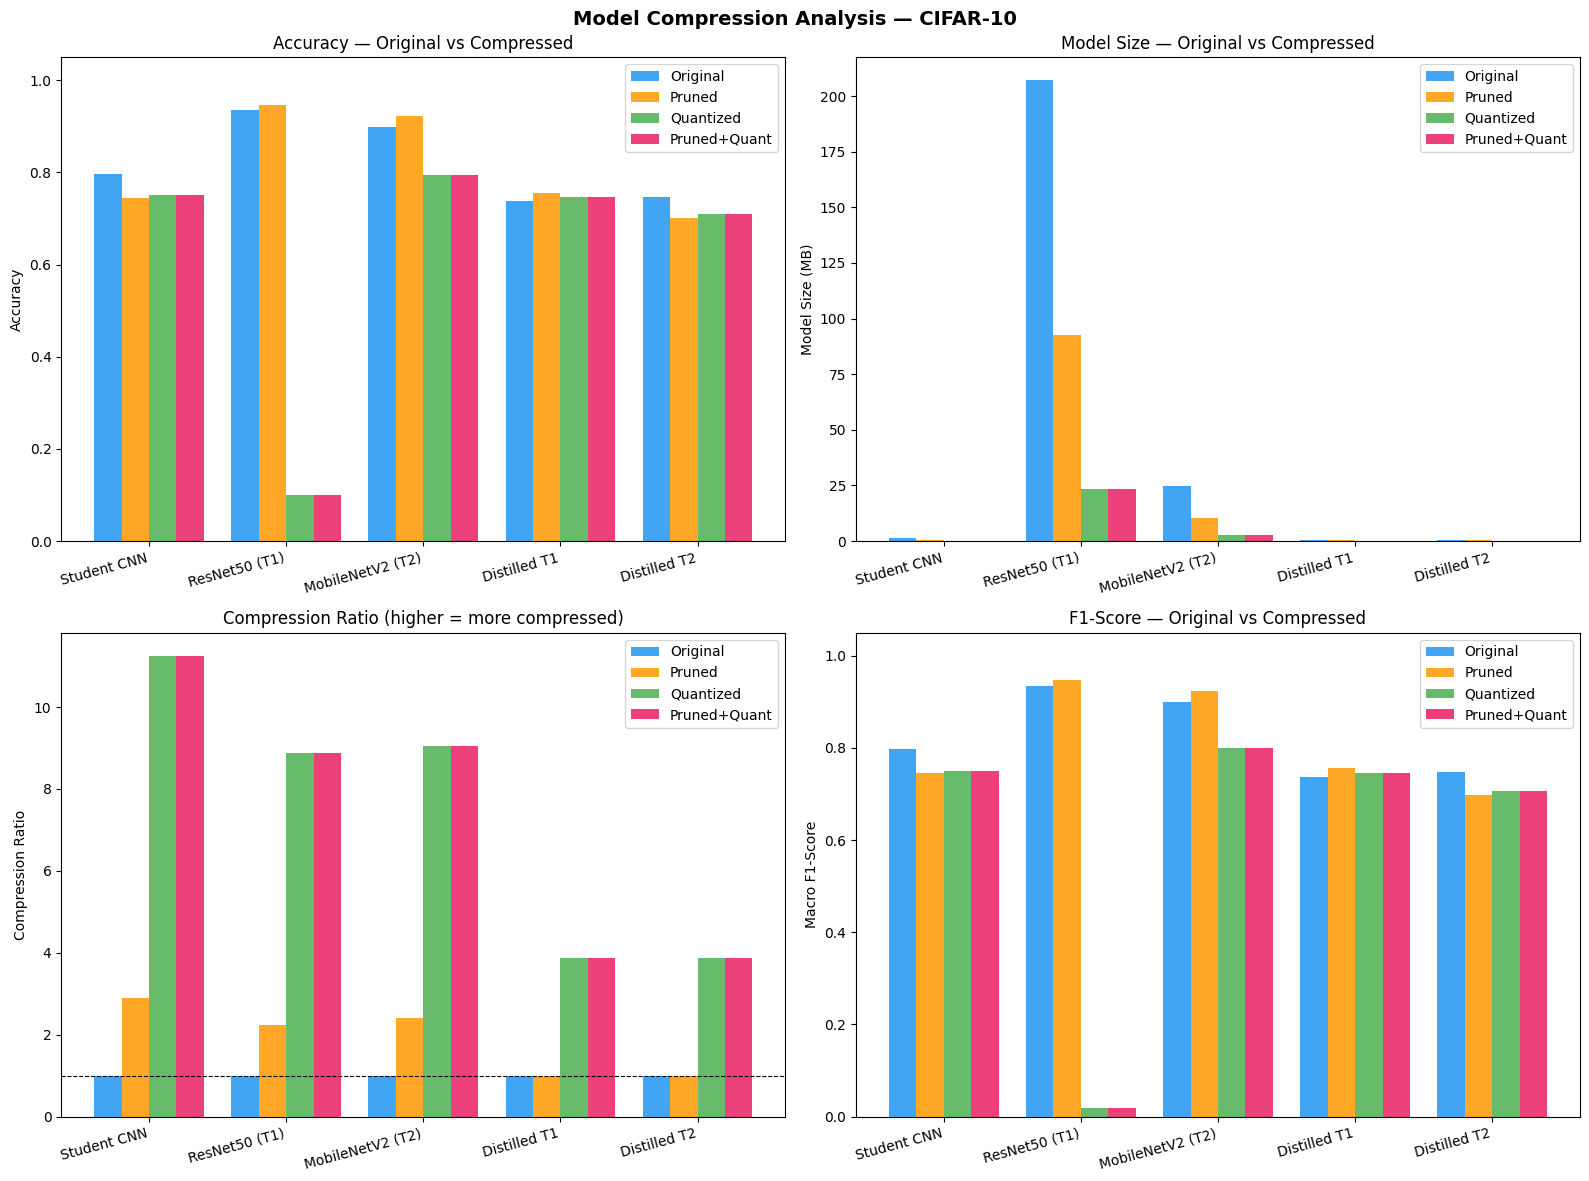

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

model_groups = {
    'Student CNN':       ['student_base', 'student_base_pruned', 'student_base_quant', 'student_base_pq'],
    'ResNet50 (T1)':     ['teacher1',     'teacher1_pruned',     'teacher1_quant',     'teacher1_pq'],
    'MobileNetV2 (T2)':  ['teacher2',     'teacher2_pruned',     'teacher2_quant',     'teacher2_pq'],
    'Distilled T1':      ['student_dist1','student_dist1_pruned','student_dist1_quant','student_dist1_pq'],
    'Distilled T2':      ['student_dist2','student_dist2_pruned','student_dist2_quant','student_dist2_pq'],
}
labels = ['Original', 'Pruned', 'Quantized', 'Pruned+Quant']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

# Plot 1: Accuracy comparison per model family
ax = axes[0, 0]
x = np.arange(len(model_groups))
width = 0.2
for i, (label, color) in enumerate(zip(labels, colors)):
    accs = [results[keys[i]]['accuracy'] for keys in model_groups.values()]
    ax.bar(x + i*width, accs, width, label=label, color=color, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(list(model_groups.keys()), rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy — Original vs Compressed')
ax.legend()
ax.set_ylim(0, 1.05)

# Plot 2: Model size comparison
ax = axes[0, 1]
for i, (label, color) in enumerate(zip(labels, colors)):
    sizes = [results[keys[i]]['size_mb'] for keys in model_groups.values()]
    ax.bar(x + i*width, sizes, width, label=label, color=color, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(list(model_groups.keys()), rotation=15, ha='right')
ax.set_ylabel('Model Size (MB)')
ax.set_title('Model Size — Original vs Compressed')
ax.legend()

# Plot 3: Compression Ratio
ax = axes[1, 0]
comp_keys = [
    ['student_base', 'teacher1', 'teacher2', 'student_dist1', 'student_dist2'],
    ['student_base_pruned', 'teacher1_pruned', 'teacher2_pruned', 'student_dist1_pruned', 'student_dist2_pruned'],
    ['student_base_quant', 'teacher1_quant', 'teacher2_quant', 'student_dist1_quant', 'student_dist2_quant'],
    ['student_base_pq', 'teacher1_pq', 'teacher2_pq', 'student_dist1_pq', 'student_dist2_pq'],
]
model_names = list(model_groups.keys())
for i, (label, color) in enumerate(zip(labels, colors)):
    base_keys = ['student_base', 'teacher1', 'teacher2', 'student_dist1', 'student_dist2']
    ratios = [round(results[bk]['size_mb'] / results[ck]['size_mb'], 2)
              for bk, ck in zip(base_keys, comp_keys[i])]
    ax.bar(x + i*width, ratios, width, label=label, color=color, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('Compression Ratio')
ax.set_title('Compression Ratio (higher = more compressed)')
ax.legend()
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8)

# Plot 4: F1 Scores
ax = axes[1, 1]
for i, (label, color) in enumerate(zip(labels, colors)):
    f1s = [results[keys[i]]['f1'] for keys in model_groups.values()]
    ax.bar(x + i*width, f1s, width, label=label, color=color, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('Macro F1-Score')
ax.set_title('F1-Score — Original vs Compressed')
ax.legend()
ax.set_ylim(0, 1.05)

plt.suptitle('Model Compression Analysis — CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 14 — Summary Statistics per Compression Strategy

In [19]:
strategy_groups = {
    'Original': ['student_base', 'teacher1', 'teacher2', 'student_dist1', 'student_dist2'],
    'Pruned':   ['student_base_pruned', 'teacher1_pruned', 'teacher2_pruned', 'student_dist1_pruned', 'student_dist2_pruned'],
    'Quantized':['student_base_quant', 'teacher1_quant', 'teacher2_quant', 'student_dist1_quant', 'student_dist2_quant'],
    'Pruned+Quant':['student_base_pq', 'teacher1_pq', 'teacher2_pq', 'student_dist1_pq', 'student_dist2_pq'],
}

print(f"\n{'Strategy':<18} {'Avg Acc':>8} {'Avg F1':>8} {'Avg Size MB':>12} {'Avg Infer(s)':>13}")
print("-" * 62)
for strategy, keys in strategy_groups.items():
    avg_acc  = np.mean([results[k]['accuracy'] for k in keys])
    avg_f1   = np.mean([results[k]['f1'] for k in keys])
    avg_size = np.mean([results[k]['size_mb'] for k in keys])
    avg_inf  = np.mean([results[k]['infer_sec'] for k in keys])
    print(f"{strategy:<18} {avg_acc:>8.4f} {avg_f1:>8.4f} {avg_size:>12.3f} {avg_inf:>13.3f}")

print("\n✅ All tasks from the assignment are complete.")
print("Tasks covered:")
print("  1. Lightweight CNN (Student) trained from scratch on CIFAR-10")
print("  2. Two pre-trained teachers fine-tuned: ResNet50, MobileNetV2")
print("  3. Knowledge Distillation: Teacher1 → Student")
print("  4. Knowledge Distillation: Teacher2 → Student")
print("  5. Pruning applied to ALL 5 models")
print("  6. Quantization (TFLite) applied to ALL 5 models")
print("  7. Pruning + Quantization combined on ALL 5 models")
print("  8. Full comparison: accuracy, precision, recall, F1, size, params, inference, compression ratio, accuracy retention")


Strategy            Avg Acc   Avg F1  Avg Size MB  Avg Infer(s)
--------------------------------------------------------------
Original             0.8233   0.8233       46.823         9.519
Pruned               0.8147   0.8141       20.832        13.638
Quantized            0.6204   0.6039        5.288        64.555
Pruned+Quant         0.6204   0.6039        5.288        63.885

✅ All tasks from the assignment are complete.
Tasks covered:
  1. Lightweight CNN (Student) trained from scratch on CIFAR-10
  2. Two pre-trained teachers fine-tuned: ResNet50, MobileNetV2
  3. Knowledge Distillation: Teacher1 → Student
  4. Knowledge Distillation: Teacher2 → Student
  5. Pruning applied to ALL 5 models
  6. Quantization (TFLite) applied to ALL 5 models
  7. Pruning + Quantization combined on ALL 5 models
  8. Full comparison: accuracy, precision, recall, F1, size, params, inference, compression ratio, accuracy retention
